# Mortgage Servicing Rights (MSR) Valuation

## Why this model was built

Mortgage Servicing Rights (MSRs) represent the right to earn servicing fees on outstanding mortgage balances over time. Unlike standard fixed-income instruments, MSRs are **highly sensitive to prepayment behavior**, making them exposed to interest-rate movements, refinancing incentives, and borrower behavior.

The purpose of this notebook is to build a **transparent, cashflow-based MSR valuation model** that explicitly links:
- mortgage balance runoff,
- prepayment assumptions,
- servicing economics, and
- discounting,

in order to clearly illustrate **what drives MSR value and risk**.

This model mirrors how MSRs are analysed in practice by banks, servicers, and structured-finance teams for valuation, risk management, and scenario analysis.

---

## What the model does

### 1. Mortgage Balance Runoff
The model starts with a single mortgage loan and projects its **monthly balance evolution** by modelling:
- scheduled amortisation,
- prepayments using a CPR/SMM framework.

As prepayments occur, the outstanding balance declines faster than contractual maturity.

This balance runoff is the **core state variable** for MSR valuation, since servicing income is earned only while the loan remains outstanding.

---

### 2. MSR Cashflow Generation
Monthly MSR cashflows are computed as:

$\text{MSR Cashflow}_t = \text{Beginning Balance}_t \times \frac{\text{Servicing Fee} + \text{Float Benefit} - \text{Cost to Service}}{12}$

This reflects the economics of mortgage servicing:
- revenue from servicing fees and ancillary benefits,
- reduced by ongoing servicing costs,
- earned only on the surviving loan balance.

As balances decline due to amortisation and prepayment, MSR cashflows decline accordingly.

---

### 3. Discounted Cashflow Valuation
Projected MSR cashflows are discounted back to present value using a constant annual discount rate.

The sum of discounted cashflows represents the **economic value of the MSR** under the chosen assumptions.

This framework allows for clear sensitivity analysis with respect to:
- prepayment speed (CPR),
- discount rate,
- servicing fee structure.

---

### 4. Scenario Analysis
The notebook evaluates MSR value under different scenarios, including:
- constant CPR assumptions,
- incentive-driven prepayment behavior under different market interest rates.

By comparing scenarios, the model highlights how MSR value responds to changes in the interest-rate environment.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, Optional

In [2]:
def annual_to_monthly_rate(r_annual: float) -> float:
    return r_annual / 12.0

def cpr_to_smm(cpr: float) -> float:
    cpr = max(0.0, min(1.0, cpr))
    return 1.0 - (1.0 - cpr) ** (1.0 / 12.0)

def monthly_discount_factors(discount_rate_annual: float, months: np.ndarray) -> np.ndarray:
    r_m = annual_to_monthly_rate(discount_rate_annual)
    return 1.0 / (1.0 + r_m) ** months

def monthly_payment(balance: float, note_rate_annual: float, term_months: int) -> float:
    r_m = annual_to_monthly_rate(note_rate_annual)
    if r_m == 0:
        return balance / term_months
    return balance * (r_m * (1 + r_m) ** term_months) / ((1 + r_m) ** term_months - 1)

In [3]:
@dataclass(frozen=True)
class Loan:
    loan_id: str
    orig_balance: float
    note_rate: float     # annual
    term_months: int

@dataclass(frozen=True)
class MSRAssumptions:
    servicing_fee_bps: float = 25.0     # bps per year on surviving UPB
    float_benefit_bps: float = 5.0      # optional: float/ancillary benefit bps
    cost_to_service_bps: float = 6.0    # servicing cost bps (reduces value)
    discount_rate: float = 0.10         # annual discount rate for MSR cashflows
    horizon_months: Optional[int] = None

In [4]:
def cpr_constant(month: int, cpr: float) -> float:
    return float(max(0.0, min(1.0, cpr)))

In [5]:
@dataclass(frozen=True)
class IncentivePrepayParams:
    base_cpr: float = 0.05
    seasoning_months: int = 24
    max_extra_cpr: float = 0.25
    slope: float = 6.0

def cpr_incentive(month: int, note_rate: float, market_rate: float, p: IncentivePrepayParams) -> float:
    seasoning = min(1.0, month / max(1, p.seasoning_months))
    base = p.base_cpr * seasoning
    incentive = max(0.0, note_rate - market_rate)
    extra = p.max_extra_cpr * (1.0 - np.exp(-p.slope * incentive))
    return float(max(0.0, min(1.0, base + extra)))

In [6]:
def msr_valuation(
    loan: Loan,
    assumptions: MSRAssumptions,
    prepay_mode: str = "CONSTANT",  # "CONSTANT" or "INCENTIVE"
    cpr_level: float = 0.08,        # used if CONSTANT
    market_rate_curve: Optional[Dict[int, float]] = None,
    incentive_params: IncentivePrepayParams = IncentivePrepayParams()
) -> pd.DataFrame:

    H = assumptions.horizon_months or loan.term_months
    H = min(H, loan.term_months)

    fee_net_bps = assumptions.servicing_fee_bps + assumptions.float_benefit_bps - assumptions.cost_to_service_bps
    fee_net_monthly = fee_net_bps / 10000.0 / 12.0

    pmt = monthly_payment(loan.orig_balance, loan.note_rate, loan.term_months)

    rows = []
    bal = loan.orig_balance

    last_curve_month = None
    if market_rate_curve:
        last_curve_month = max(market_rate_curve.keys())

    for m in range(1, H + 1):
        if bal <= 1e-6:
            break

        # scheduled amortization
        r_m = annual_to_monthly_rate(loan.note_rate)
        interest = bal * r_m
        sched_prin = max(0.0, min(bal, pmt - interest))
        bal_after_sched = bal - sched_prin

        # CPR selection
        if prepay_mode.upper() == "CONSTANT":
            cpr = cpr_constant(m, cpr_level)
        elif prepay_mode.upper() == "INCENTIVE":
            if market_rate_curve is None:
                raise ValueError("market_rate_curve is required for INCENTIVE mode.")
            mkt = market_rate_curve.get(m, market_rate_curve[last_curve_month])
            cpr = cpr_incentive(m, loan.note_rate, mkt, incentive_params)
        else:
            raise ValueError("prepay_mode must be 'CONSTANT' or 'INCENTIVE'.")

        smm = cpr_to_smm(cpr)
        prepay_prin = min(bal_after_sched, smm * bal_after_sched)

        end_bal = max(0.0, bal_after_sched - prepay_prin)

        # MSR cashflow on beginning balance (common simplified convention)
        msr_cf = bal * fee_net_monthly

        rows.append({
            "month": m,
            "begin_balance": bal,
            "interest": interest,
            "sched_principal": sched_prin,
            "prepay_principal": prepay_prin,
            "end_balance": end_bal,
            "cpr": cpr,
            "msr_cashflow": msr_cf
        })

        bal = end_bal

    df = pd.DataFrame(rows)
    df["df"] = monthly_discount_factors(assumptions.discount_rate, df["month"].values)
    df["pv_msr_cf"] = df["msr_cashflow"] * df["df"]
    return df

In [7]:
loan = Loan("MSR_L1", orig_balance=500_000, note_rate=0.0675, term_months=360)

assump = MSRAssumptions(
    servicing_fee_bps=25,
    float_benefit_bps=5,
    cost_to_service_bps=6,
    discount_rate=0.10
)

df_base = msr_valuation(
    loan=loan,
    assumptions=assump,
    prepay_mode="CONSTANT",
    cpr_level=0.08
)

msr_pv = df_base["pv_msr_cf"].sum()
msr_pv

4828.546589176533

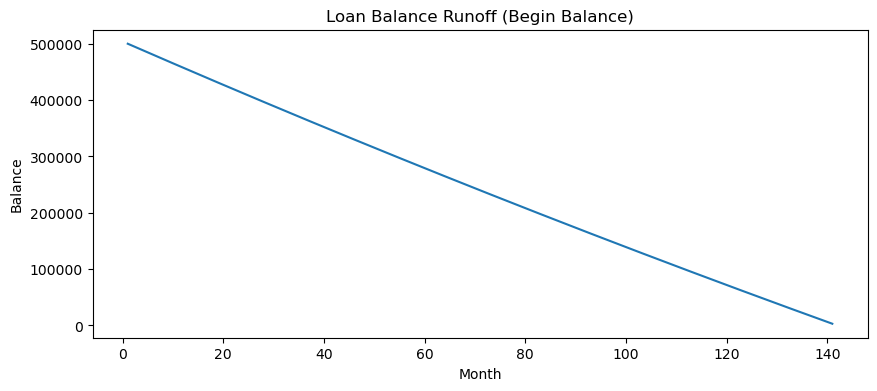

In [8]:
plt.figure(figsize=(10,4))
plt.plot(df_base["month"], df_base["begin_balance"])
plt.title("Loan Balance Runoff (Begin Balance)")
plt.xlabel("Month")
plt.ylabel("Balance")
plt.show()

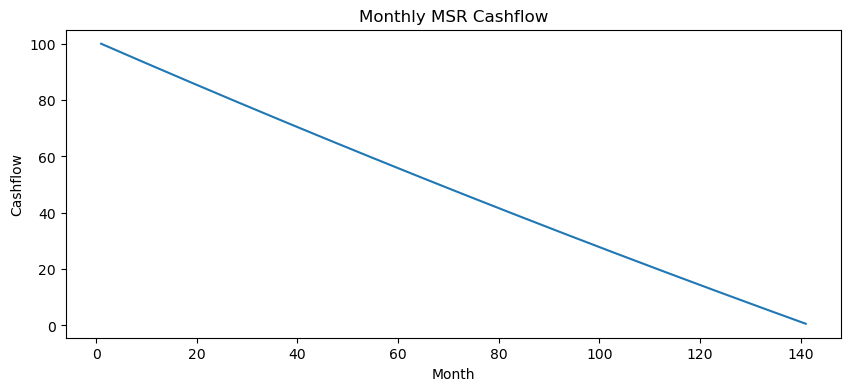

In [9]:
plt.figure(figsize=(10,4))
plt.plot(df_base["month"], df_base["msr_cashflow"])
plt.title("Monthly MSR Cashflow")
plt.xlabel("Month")
plt.ylabel("Cashflow")
plt.show()

In [10]:
cprs = np.array([0.04, 0.06, 0.08, 0.10, 0.12, 0.15])
disc = np.array([0.08, 0.10, 0.12, 0.14])

grid = []
for cpr in cprs:
    for d in disc:
        a = MSRAssumptions(
            servicing_fee_bps=assump.servicing_fee_bps,
            float_benefit_bps=assump.float_benefit_bps,
            cost_to_service_bps=assump.cost_to_service_bps,
            discount_rate=float(d)
        )
        df = msr_valuation(loan, a, prepay_mode="CONSTANT", cpr_level=float(cpr))
        grid.append({
            "CPR": cpr,
            "DiscountRate": d,
            "MSR_PV": df["pv_msr_cf"].sum()
        })

sens = pd.DataFrame(grid).pivot(index="CPR", columns="DiscountRate", values="MSR_PV")
sens

DiscountRate,0.08,0.10,0.12,0.14
CPR,,,,
0.04,6857.576476,6291.307046,5797.912044,5365.885425
0.06,5870.891121,5452.842386,5081.365075,4750.078298
0.08,5153.222116,4828.546589,4536.006601,4271.680178
0.10,4600.634744,4339.766224,4102.231876,3885.451493
0.12,4158.381113,3943.581828,3746.356358,3564.922865
0.15,3635.054235,3469.073774,3315.167714,3172.243595


In [11]:
def flat_curve(rate: float, months: int) -> Dict[int, float]:
    return {m: rate for m in range(1, months+1)}

curve_5 = flat_curve(0.05, 360)
curve_7 = flat_curve(0.07, 360)

df_5 = msr_valuation(loan, assump, prepay_mode="INCENTIVE", market_rate_curve=curve_5)
df_7 = msr_valuation(loan, assump, prepay_mode="INCENTIVE", market_rate_curve=curve_7)

pv_5 = df_5["pv_msr_cf"].sum()
pv_7 = df_7["pv_msr_cf"].sum()
pv_5, pv_7

(5333.686189275286, 6289.978438024906)

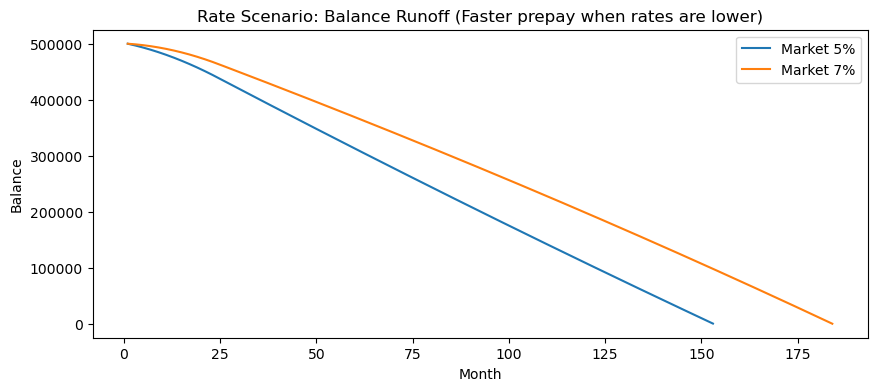

In [12]:
plt.figure(figsize=(10,4))
plt.plot(df_5["month"], df_5["begin_balance"], label="Market 5%")
plt.plot(df_7["month"], df_7["begin_balance"], label="Market 7%")
plt.title("Rate Scenario: Balance Runoff (Faster prepay when rates are lower)")
plt.xlabel("Month")
plt.ylabel("Balance")
plt.legend()
plt.show()

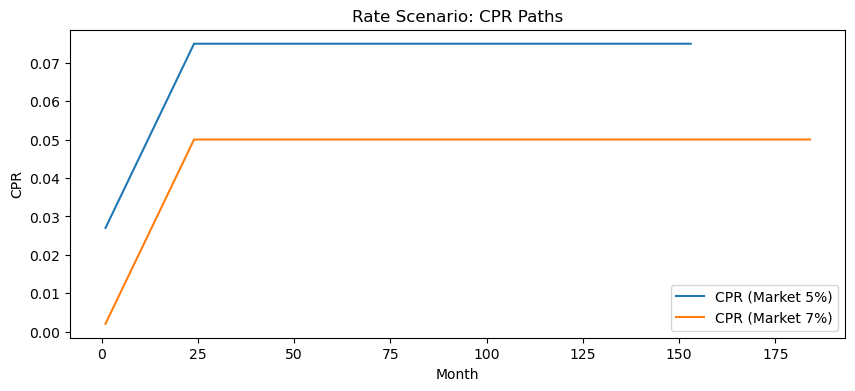

In [13]:
plt.figure(figsize=(10,4))
plt.plot(df_5["month"], df_5["cpr"], label="CPR (Market 5%)")
plt.plot(df_7["month"], df_7["cpr"], label="CPR (Market 7%)")
plt.title("Rate Scenario: CPR Paths")
plt.xlabel("Month")
plt.ylabel("CPR")
plt.legend()
plt.show()

In [14]:
from pathlib import Path

def export_msr(df: pd.DataFrame, out_dir="outputs", name="msr_model"):
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)

    xlsx = out / f"{name}.xlsx"
    pq = out / f"{name}.parquet"

    with pd.ExcelWriter(xlsx, engine="openpyxl") as w:
        df.to_excel(w, sheet_name="msr_cashflows", index=False)

    df.to_parquet(pq, index=False)

    return str(xlsx), str(pq)

export_msr(df_base, name="msr_constant_cpr")

('outputs\\msr_constant_cpr.xlsx', 'outputs\\msr_constant_cpr.parquet')

In [17]:
msr_const = pd.read_excel(r"C:\Users\gtmlv\Downloads\msr_constant_cpr.xlsx")

In [18]:
msr_const.head()

,month,begin_balance,interest,sched_principal,prepay_principal,end_balance,cpr,msr_cashflow,df,pv_msr_cf
0,1,500000.000000,2812.500000,430.490483,3459.210433,496110.299084,0.08,100.000000,0.991736,99.173554
1,2,496110.299084,2790.620432,452.370050,3432.125153,492225.803880,0.08,99.222060,0.983539,97.588803
2,3,492225.803880,2768.770147,474.220336,3405.076123,488346.507421,0.08,98.445161,0.975411,96.024488
3,4,488346.507421,2746.949104,496.041379,3378.063292,484472.402751,0.08,97.669301,0.967350,94.480370
4,5,484472.402751,2725.157265,517.833217,3351.086614,480603.482919,0.08,96.894481,0.959355,92.956212


## Results & Interpretation

### MSR Cashflow Profile
The model produces a **front-loaded MSR cashflow stream**:
- large servicing income in early months when balances are high,
- rapidly declining cashflows as prepayments reduce outstanding balance,
- a long but low-value tail.

This confirms that MSRs behave like a **declining annuity** rather than a traditional bond.

---

### Sensitivity to Prepayment
The results show that:
- faster prepayments significantly reduce MSR value,
- early-life prepayments are especially damaging due to discounting.

This explains why MSRs lose value sharply in **rate-down environments**, when refinancing activity accelerates.

---

### Interest-Rate Impact
When market rates are lower than the loan’s note rate:
- refinancing incentives increase,
- CPR rises,
- mortgage balances run off faster,
- MSR cashflows terminate earlier.

Conversely, higher market rates reduce refinancing incentives and extend MSR cashflows.

**Key insight:**  
MSRs exhibit **negative convexity** — their value falls when rates decline and does not increase symmetrically when rates rise.

---

## Key Takeaways

- MSR value is driven primarily by **prepayment timing**, not credit risk
- Servicing cashflows are highly front-loaded
- Interest-rate movements affect MSRs indirectly through borrower behavior
- Cashflow-based modelling provides clear economic intuition and explainability

---

## Conclusion

This notebook demonstrates a practical MSR valuation framework that explicitly connects mortgage runoff, servicing economics, and discounting. The results highlight why MSRs are among the most interest-rate-sensitive assets in mortgage finance and why accurate prepayment modelling is central to MSR risk management and valuation.